Defining Simulator

In [15]:
import numpy as np

_ = np.random.seed(0)

def lotka_volterra(y, alpha, beta, delta, gamma):
    prey, predator = y
    dprey_dt = alpha * prey - beta * prey * predator
    dpredator_dt = delta * prey * predator - gamma * predator
    return np.asarray([dprey_dt, dpredator_dt])

def simulate(parameters):
    alpha = parameters[0]
    beta = parameters[1]
    delta = parameters[2]
    gamma = parameters[3]

    y0 = np.asarray([40.0, 9.0])  # Initial populations
    t_span = 200  # Total simulation time
    dt = 0.1  # Time step

    timesteps = int(t_span / dt)
    y = np.zeros((timesteps, 2))
    y[0] = y0

    for i in range(1, timesteps):
        y[i] = y[i-1] + lotka_volterra(y[i-1], alpha, beta, delta, gamma) * dt

    return y

C:\Users\vasir\AppData\Local\Temp\ipykernel_35092\1255746376.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(url, delim_whitespace=True, header=None, index_col=0)


(91, 2)


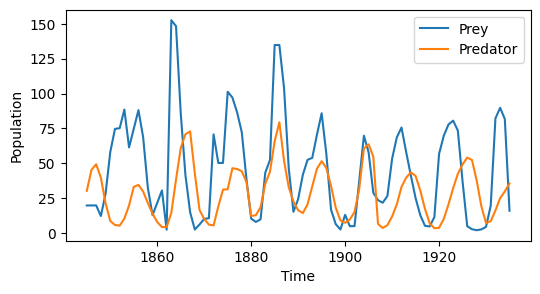

In [33]:
import matplotlib.pyplot as plt
import pandas as pd

#time_vec = np.arange(0, 200, 0.1)
#observation = simulate(np.asarray([0.1, 0.02, 0.01, 0.1]))

url = 'http://people.whitman.edu/~hundledr/courses/M250F03/LynxHare.txt'

df = pd.read_csv(url, delim_whitespace=True, header=None, index_col=0)
df.index.name = 'Year'
df.columns = ['Hare', 'Lynx']
#df.plot(figsize=(10,6), grid=True)
time_vec = df.index.values
observation = df[['Hare', 'Lynx']].values
print(observation.shape)
n_obs = observation.shape[0]
sigma_hare = 0.2 * np.std(observation[:, 0])   # 20% of hare std
sigma_lynx = 0.2 * np.std(observation[:, 1])   # 20% of lynx std

fig, ax = plt.subplots(1, 1, figsize=(6, 3))
_ = ax.plot(time_vec, observation)
_ = ax.legend(["Prey", "Predator"])
_ = ax.set_xlabel("Time")
_ = ax.set_ylabel("Population")

Add noise and define summary stats - here we choose max and mean of populations

# LOOK AT NOISE AND MISSPECIFICATION AND WHAT THEY MEAN AND ADD AND HOW TO DO IT

In [17]:
def summarize_simulation(simulation_result):
    
    ''' WE ARE CHANGING THIS TO ADD NOISE SEPERATELY
    observation_noise = np.reshape(
        np.random.randn(2000 * 2),
        (2000, 2)
    )
    noisy_sim = simulation_result + observation_noise

    prey_population = noisy_sim[:, 0]
    predator_population = noisy_sim[:, 1]
    '''
    prey_population = simulation_result[:, 0]
    predator_population = simulation_result[:, 1]
    
    summary = [
        np.max(prey_population).item(),
        np.max(predator_population).item(),
        np.mean(prey_population).item(),
        np.mean(predator_population).item()
    ]
    return np.asarray(summary)

In [ ]:
def downsample_to_n_obs(sim_result, n_obs):
    # pick out n_obs points to ensure arrays are same size
    T = sim_result.shape[0]
    idx = np.linspace(0, T - 1, n_obs).astype(int)
    return sim_result[idx]

def simulate_match_data(parameters, n_obs):
    # returns data that is same size as observed, adding no noise
    full_traj = simulate(parameters)            # (2000, 2)
    return downsample_to_n_obs(full_traj, n_obs)  # (n_obs, 2)

In [29]:
def simulate_gaussian(parameters, n_obs, sigma_hare, sigma_lynx):
    """
    Run the LV simulator, downsample to n_obs points,
    then add Gaussian observation noise to both species.

    parameters: array-like of length 4 (alpha, beta, delta, gamma)
    n_obs: number of observation points (91 for your data)
    sigma_hare, sigma_lynx: std dev of observation noise for each species
    """

    # 1) Get the latent (noise-free) LV trajectory on the data grid
    latent = simulate_match_data(parameters, n_obs)
    # latent.shape == (91, 2)

    # 2) Build a noise array of the same shape, with different std per species
    noise = np.random.normal(
        loc=0.0,
        scale=np.array([sigma_hare, sigma_lynx]),  # one sigma per column
        size=latent.shape
    )
    # noise.shape == (91, 2)
    # Column 0 ~ N(0, sigma_hare^2), column 1 ~ N(0, sigma_lynx^2)

    # 3) Add noise to the latent trajectory to get simulated observations
    noisy = latent + noise

    return noisy

In [ ]:
def simulate_poisson(parameters, n_obs):
    latent = simulate_match_data(parameters, n_obs)
    lam = np.clip(latent, 1e-6, None)
    noisy_counts = np.random.poisson(lam)
    return noisy_counts

In [ ]:
def simulator_distribution(distn, parameters, n_obs):
    if distn == 'none':
        result = simulate_match_data(parameters, n_obs)
    elif distn == 'gaussian':
        result = simulate_gaussian(parameters, n_obs, sigma_hare, sigma_lynx)
    elif distn == 'poisson':
        result = simulate_poisson(parameters, n_obs)
    else:
        raise ValueError(f"Unknown distribution type: {distn}")
    return result

Define a uniform prior

In [19]:
import torch

_ = torch.manual_seed(42)
from sbi.utils import BoxUniform

lower_bound = torch.as_tensor([0.05, 0.01, 0.005, 0.005])
upper_bound = torch.as_tensor([0.15, 0.03, 0.03, 0.15])
prior = BoxUniform(low=lower_bound, high=upper_bound)

Generate Prior Samples. Then define a function to run sims in parallel. Then generate x samples

In [ ]:
theta = prior.sample((10_000,))

from joblib import Parallel, delayed


def parallel_simulate(theta,distn):
    # Our simulator uses numpy, but prior samples are in PyTorch.
    theta_np = theta.numpy()

    num_workers = 8
    simulation_outputs = Parallel(n_jobs=num_workers)(
        delayed(simulator_distribution)(distn,batch,n_obs)
        for batch in theta_np
    )
    return np.asarray(simulation_outputs)

# This takes a few seconds.
simulation_outputs = parallel_simulate(theta,'poisson')
x = torch.as_tensor(np.asarray([summarize_simulation(sim) for sim in simulation_outputs]), dtype=torch.float32)

print("theta.shape", theta.shape)
print("x.shape", x.shape)

theta.shape torch.Size([10000, 4])
x.shape torch.Size([10000, 4])


Now before training model, do a sanity check to see if the simulations cover the observation. Compute summary statisitcs and visual simn ouputs and obs

(4,)


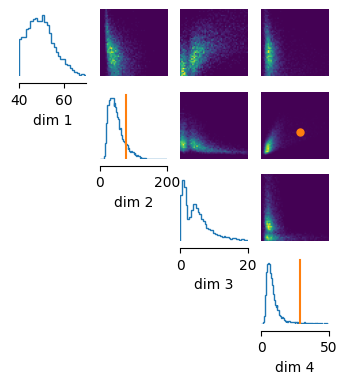

In [35]:
x_obs = summarize_simulation(observation)
print(x_obs.shape)

from sbi.analysis import pairplot

_ = pairplot(
    samples=x,
    points=x_obs[None, :],  # `points` needs a batch dimension.
    limits=[[40, 70], [0, 200], [0, 20], [0, 50]],
    figsize=(4, 4),
)

[NOTE DIM 1 AND 3 LOOK KINDA BAD HERE, SHOULD COVER MORE?]

Set up neural network. In this case use NPE, w/ *nerual spline flow??* [ask about this], train on simulations, check convergence to see if more loops needed:

 Training neural network. Epochs trained: 151

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=c:\Users\vasir\Documents\0 Research Project\Lotka-Volterra\sbi-logs\NPE_C\2025-11-16T21_08_11.088479' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


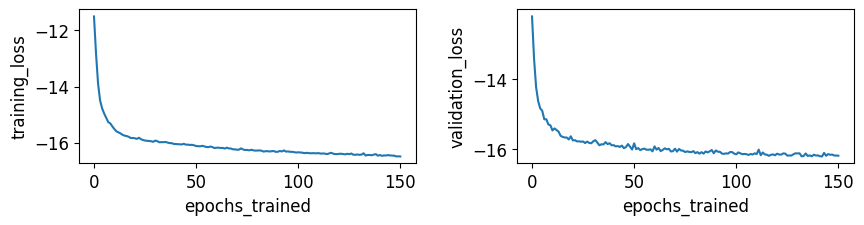

In [36]:
from sbi.inference import NPE

inference = NPE(density_estimator="nsf")
posterior_net = inference.append_simulations(theta, x).train(max_num_epochs=150, stop_after_epochs=30)

from sbi.analysis import plot_summary

_ = plot_summary(
    inference,
    tags=["training_loss", "validation_loss"],
    figsize=(10, 2),
)

Build Posterior, and sample from it. We can do this quite easily as amortized. Plot to visualize. 

In [23]:
posterior = inference.build_posterior()
print(posterior)

Posterior p(θ|x) of type DirectPosterior. It samples the posterior network and rejects samples that
            lie outside of the prior bounds.


In [24]:
print("Observation: ", x_obs)

Observation:  [152.65        79.35        45.40648352  28.33659341]


  0%|          | 0/1000 [00:00<?, ?it/s]

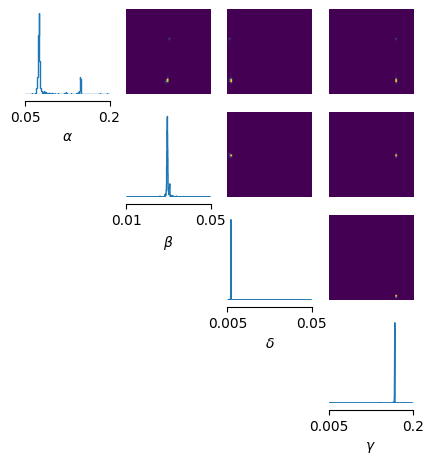

In [25]:
samples = posterior.sample((1_000,), x=x_obs)

from sbi.analysis import pairplot

_ = pairplot(
    samples,
    limits=[[0.05, 0.2], [0.01, 0.05], [0.005, 0.05], [0.005, 0.2]],
    ticks=[[0.05, 0.2], [0.01, 0.05], [0.005, 0.05], [0.005, 0.2]],
    figsize=(5, 5),
    labels=[r"$\alpha$", r"$\beta$", r"$\delta$", r"$\gamma$"]
)

#### Diagnostic Checks: very impt to see if posterior produced is correct?

Posterior predictive checks: see if posterior samples look similar to the observation. Adhoc/heurisitc

  0%|          | 0/10 [00:00<?, ?it/s]

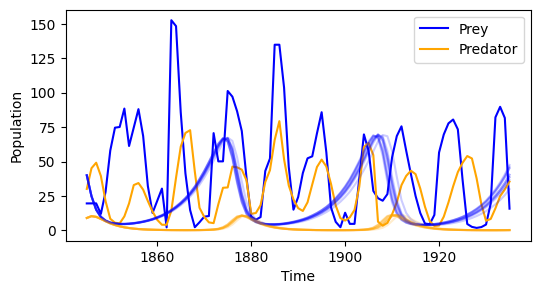

In [26]:
posterior_samples = posterior.sample((10,), x=x_obs)
posterior_predictives = parallel_simulate(posterior_samples)

posterior_predictive_summary_stats = torch.as_tensor(
    np.asarray([summarize_simulation(sim) for sim in simulation_outputs]),
    dtype=torch.float32
)
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
_ = ax.plot(time_vec, observation[:, 0], c="b")
_ = ax.plot(time_vec, observation[:, 1], c="orange")
for i in range(10):
    _ = ax.plot(time_vec, posterior_predictives[i, :, 0], c="b", alpha=0.2)
    _ = ax.plot(time_vec, posterior_predictives[i, :, 1], c="orange", alpha=0.2)
_ = ax.legend(["Prey", "Predator"])
_ = ax.set_xlabel("Time")
_ = ax.set_ylabel("Population")

Simulation-based Calibration: Quantitative assement of fit, but require more simulaiotns. Check if uncertainty too high/low/wide/skewed

In [27]:
num_sbc_samples = 200  # choose a number of sbc runs, should be ~100s

prior_samples = prior.sample((num_sbc_samples,))

prior_predictives = parallel_simulate(prior_samples)
prior_predictive_summary_stats = torch.as_tensor(
    np.asarray([summarize_simulation(sim) for sim in prior_predictives]),
    dtype=torch.float32
)

from sbi.diagnostics import run_sbc

# run SBC: for each inference we draw 1000 posterior samples.
num_posterior_samples = 1_000
ranks, dap_samples = run_sbc(
    prior_samples,
    prior_predictive_summary_stats,
    posterior,
    reduce_fns=lambda theta, x: -posterior.log_prob(theta, x),
    num_posterior_samples=num_posterior_samples,
    use_batched_sampling=False,  # `True` can give speed-ups, but can cause memory issues.
)


Sampling 200 times (1000,) posterior samples.: 100%|██████████| 200/200 [00:06<00:00, 31.86it/s]


Calculating ranks for 200 SBC samples:   0%|          | 0/200 [00:00<?, ?it/s]

Can then also plot using sbc_rank_plot

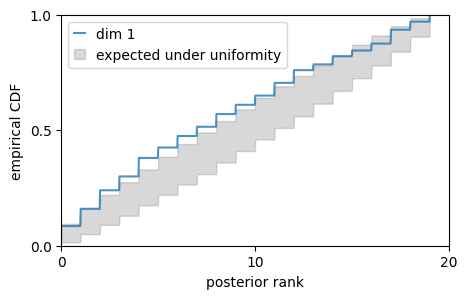

In [28]:
from sbi.analysis.plot import sbc_rank_plot

fig, ax = sbc_rank_plot(
    ranks,
    num_posterior_samples,
    plot_type="cdf",
    num_bins=20,
    figsize=(5, 3),
)